# 6. Agentic Workloads

By [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)) and [Claude Code](https://claude.com/claude-code) 🤖

Every workload so far has been a *request*: a prompt arrives, an answer streams
back, the request is gone. An agent works differently. Given one task — "find
which main course disappeared from this restaurant's menu between two dates" — it
issues dozens of LLM requests: it plans, picks a worker, calls a search tool,
reads the result, calls another tool, writes code, runs it, reads the error,
tries again, and finally answers. The user waits for the whole chain.

Three consequences shape everything in this lecture. The requests are
*dependent*: turn *k+1* cannot start until turn *k* has finished and its tool
call has returned, so the serving system has no say in how much of the work runs
at once. The prompts are long and repetitive, because each turn resends the whole
conversation plus the new tool output, which is lecture 5's problem in its most
extreme form. And the thing a user waits for is the task, not the request: a p99
TTFT of 200 ms says little if the task takes six minutes.

The lecture works from recorded traces rather than a synthetic workload. They come
from [GAIATrace](https://github.com/psu-paws/Vidur-Agent)
([Kim et al., IISWC '26](https://arxiv.org/abs/2606.01725)), which recorded every
LLM request two agent systems issued while solving tasks from GAIA
([Mialon et al., ICLR '24](https://openreview.net/forum?id=fibxvahvs3)), a
benchmark of questions that need browsing, file handling and code to answer. The
corpus covers [OWL](https://github.com/camel-ai/owl)
([Hu et al., NeurIPS '25](https://arxiv.org/abs/2505.23885)), a multi-agent system,
and [MiroThinker](https://github.com/MiroMindAI/MiroThinker), a single agent with a
summariser; we use OWL here. Each request carries its prompt and output token ids,
the turns it depended on, and a separately measured tool latency. The traces ship
with the simulator, so they are already on your disk after `lsg.setup()`.

:::{admonition} Learning goals
- Describe the structure of an agent session: turns, roles, dependencies,
  fan-out, and tool time.
- Explain why agent traffic is prompt-heavy in tokens but decode-heavy in time.
- Measure KV cache hit rates on a real agent trace and explain where the hits
  come from.
- Reason about task-level latency: what the critical path is, and which
  serving-system knobs can and cannot shorten it.
- Say which parts of this setup a production agent deployment would recognise,
  and which are artefacts of the lab.
:::

## Setup

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/faculty/kvm6242/.llm-systems-wo-gpus/backend


`lsg.gaia_sessions` loads recorded sessions, one row per LLM request. We take 24
of them out of the 165 tasks OWL ran. Sessions containing a request longer than
the course's runtime predictor was fitted for are skipped, which removes the
largest tasks — the full recording has requests of over 100,000 tokens. The last
section of the lecture collects that and the other differences from a production
deployment.

In [2]:
sessions = lsg.gaia_sessions(num_sessions=24, seed=0)
print(f"{sessions.session.nunique()} sessions, {len(sessions)} LLM requests")
sessions.drop(columns="token_ids").head(8)

24 sessions, 673 LLM requests


,session,turn,role,model,dep,num_prefill_tokens,num_decode_tokens,tool_time
0,0,0,plan,gpt-4o,[],1355,199,0.000000
1,0,1,coordinate,gpt-oss-120b,[0],583,108,0.000000
2,0,2,web search,gpt-4o,[1],1500,36,0.000000
3,0,3,web search,gpt-4o,[2],1582,114,1.164357
4,0,4,coordinate,gpt-oss-120b,[3],1044,76,0.000000
5,0,5,coordinate,gpt-oss-120b,[4],1060,59,0.000000
6,0,6,web search,gpt-4o,[5],1610,36,0.000000
7,0,7,web search,gpt-4o,[6],1692,35,0.591392


Each row is one request to the model:

- `session` / `turn`: which task, and the position in it.
- `role`: which agent inside the system issued it. OWL is a *multi-agent* system:
  a planner splits the task, a coordinator assigns each subtask to a worker, and
  the workers (web search, code, browser, document reader) do it.
- `model`: which model served the request in the recording. OWL uses two, which
  GAIATrace calls the *main* and *sub* models, and gives each a different set of
  roles.
- `dep`: the turns that must finish before this one is released.
- `tool_time`: how long the tool call that this turn waited for actually took,
  measured by re-running the tool outside the agent.

:::{note}
The traces are released under CC-BY-4.0 as part of GAIATrace. The tasks
themselves come from the GAIA benchmark, whose
[dataset terms](https://huggingface.co/datasets/gaia-benchmark/GAIA) govern its
questions; what follows are short excerpts from one recorded run, shown so you
can see what a real agent prompt is made of.
:::

## What the model actually sees

The traces carry token ids, so we can read the requests back. Let's look at the
first turns of one session. (`lsg.decode` uses the same tokenizer the traces were
built with; it downloads a small vocabulary file the first time.)

In [3]:
def show(i, head=0, tail=0, out=400):
    """Print a trimmed view of request i's prompt and of what the model generated."""
    r = sessions.iloc[i]
    ids = json.loads(r.token_ids)
    prompt, output = lsg.decode(ids[:r.num_prefill_tokens]), lsg.decode(ids[r.num_prefill_tokens:])
    print(f"=== session {r.session} turn {r.turn} | role: {r.role} | "
          f"{r.num_prefill_tokens:,} prompt + {r.num_decode_tokens} output tokens "
          f"| tool wait before it: {r.tool_time:.1f} s")
    if head:
        print("--- prompt, first lines " + "-" * 40); print(prompt[:head].strip())
    if tail:
        print("--- prompt, last lines " + "-" * 41); print(prompt[-tail:].strip())
    print("--- generated " + "-" * 50); print(output[:out].strip(), "\n")

show(0, head=620, out=560)

=== session 0 turn 0 | role: plan | 1,355 prompt + 199 output tokens | tool wait before it: 0.0 s
--- prompt, first lines ----------------------------------------
<|start|>developer<|message|># Instructions

You are going to compose and decompose tasks.

<|end|><|start|>user<|message|>You need to split the given task into 
subtasks according to the workers available in the group.
The content of the task is:

I went to Virtue restaurant & bar in Chicago for my birthday on March 22, 2021 and the main course I had was delicious!  Unfortunately, when I went back about a month later on April 21, it was no longer on the dinner menu.  Using the Wayback Machine, can you help me figure out which main course was on the dinner menu for Virtue on March 2
--- generated --------------------------------------------------
<|channel|>final<|message|><tasks>
<task>Use the Wayback Machine to find the archived dinner menu for Virtue restaurant & bar in Chicago on March 22, 2021.</task>
<task>Use the Wayba

That is the planner: it receives the user's task and a description of the
available workers, and emits a list of subtasks. Everything is marked up with
the model's chat template (`<|start|>`, `<|message|>`, `<|end|>`); the
`<|channel|>final` and `<|channel|>analysis` markers separate the answer from the
model's own reasoning.

Two turns later, a web-search worker decides to call a tool. Its entire output is
36 tokens of JSON — the call itself:

In [4]:
show(2, out=300)

=== session 0 turn 2 | role: web search | 1,500 prompt + 36 output tokens | tool wait before it: 0.0 s
--- generated --------------------------------------------------
<|channel|>commentary to=functions.search_archived_webpage <|constrain|>json<|message|>{"url":"https://www.virtuerestaurant.com/","date":"20210322"}<|call|> 



The agent executes that call, which takes 1.2 s, and sends the *result back as
part of the next prompt*. Here is the end of the next request's prompt, which is
exactly the previous prompt, plus the previous output, plus the tool result:

In [5]:
show(3, tail=430, out=330)

=== session 0 turn 3 | role: web search | 1,582 prompt + 114 output tokens | tool wait before it: 1.2 s
--- prompt, last lines -----------------------------------------
code to process it)<|end|><|start|>assistant<|channel|>commentary to=functions.search_archived_webpage <|constrain|>json<|message|>{"url":"https://www.virtuerestaurant.com/","date":"20210322"}<|call|><|start|>functions.search_archived_webpage to=assistant<|channel|>commentary<|message|>(False, 'The url https://www.virtuerestaurant.com/ was not archived on Wayback Machine, please try a different url.')<|end|><|start|>assistant
--- generated --------------------------------------------------
<|channel|>final<|message|>The Wayback Machine does not have an archived version of the Virtue restaurant & bar website for March 22, 2021. This means I cannot directly retrieve the dinner menu for that specific date using the Wayback Machine.

As a next step, I suggest trying to find any other sources or databases that might ha 



This is the mechanism behind everything in this lecture. Nothing is remembered
between requests, so each turn re-sends the whole conversation, and the prompt
grows along a branch until that worker is done. Almost every prompt is some
earlier prompt with text appended to it, which is the exact condition lecture 5
said a prefix cache needs.

## The shape of an agent session

Let's look at one whole session: how the prompt grows, which role issues each
turn, and where the tool time goes.

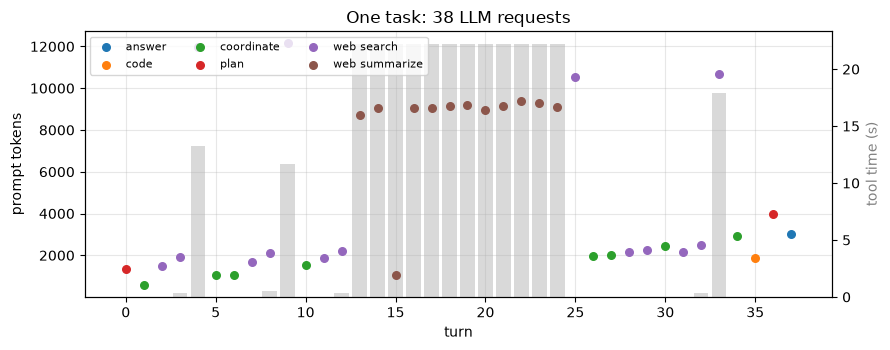

In [6]:
one = sessions[sessions.session == 4]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax2 = ax.twinx()
ax2.bar(one["turn"], one["tool_time"], color="0.85", zorder=0, width=.8)
ax2.set_ylabel("tool time (s)", color="0.5")
ax2.grid(False)
for role, g in one.groupby("role"):
    ax.scatter(g["turn"], g["num_prefill_tokens"], label=role, s=30, zorder=3)
ax.set(xlabel="turn", ylabel="prompt tokens", title=f"One task: {len(one)} LLM requests")
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend(fontsize=8, ncol=3, loc="upper left")
fig.tight_layout()

The prompt grows inside a stretch of turns and then drops: each time the
coordinator hands a subtask to a fresh worker, that worker starts a new
conversation with its own system prompt. Within a worker's stretch, every turn
adds a tool result to the prompt.

The flat band of twelve large turns in the middle is not a conversation at all.
It is a **fan-out**: the web worker retrieved a long page, split it into twelve
pieces, and asked the model about each piece *in parallel*. They all depend on
the same turn and a later turn joins them:

In [7]:
one[one["role"] == "web summarize"].drop(columns="token_ids").head(4)

,session,turn,role,model,dep,num_prefill_tokens,num_decode_tokens,tool_time
140,4,13,web summarize,gpt-oss-120b,[12],8698,79,22.205766
141,4,14,web summarize,gpt-oss-120b,[12],9043,77,22.205766
142,4,15,web summarize,gpt-oss-120b,[12],1034,99,22.205766
143,4,16,web summarize,gpt-oss-120b,[12],9059,178,22.205766


All twelve are released at the same instant, each with about 9,000 prompt tokens:
100,000 tokens of prefill arriving at one replica at once, after a 22 s tool call
during which that replica had nothing from this session to do. Bursts like this
are not an accident of load; they are what the agent's own control flow produces.

## Tokens, time, and tools

Now the whole sample. Three numbers decide what this workload does to a serving
system:

In [8]:
tokens = pd.Series({
    "requests": len(sessions),
    "requests per session (median)": sessions.groupby("session").size().median(),
    "prompt tokens (total)": sessions.num_prefill_tokens.sum(),
    "output tokens (total)": sessions.num_decode_tokens.sum(),
    "prompt : output": sessions.num_prefill_tokens.sum() / sessions.num_decode_tokens.sum(),
    "median prompt tokens": sessions.num_prefill_tokens.median(),
    "median output tokens": sessions.num_decode_tokens.median(),
    "turns waiting on a tool": (sessions.tool_time > 0).mean(),
    "tool time, median of those (s)": sessions.loc[sessions.tool_time > 0, "tool_time"].median(),
})
tokens.round(2)

requests                              673.00
requests per session (median)          25.00
prompt tokens (total)             1987165.00
output tokens (total)              173021.00
prompt : output                        11.49
median prompt tokens                 1964.00
median output tokens                  109.00
turns waiting on a tool                 0.34
tool time, median of those (s)          0.37
dtype: float64

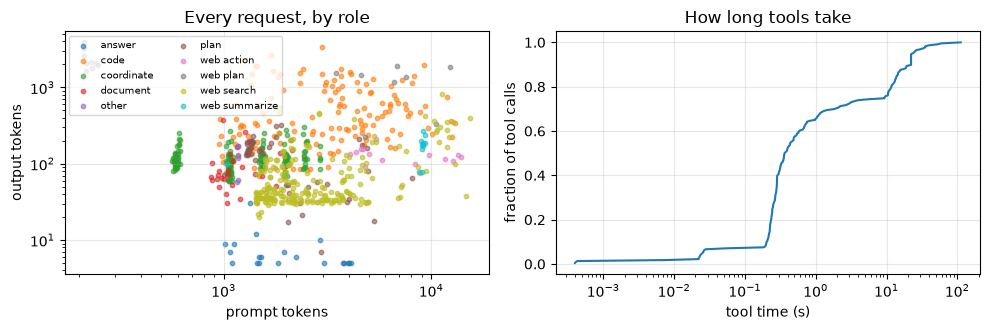

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for role, g in sessions.groupby("role"):
    ax[0].scatter(g["num_prefill_tokens"], g["num_decode_tokens"], s=10, alpha=.6, label=role)
ax[0].set(xlabel="prompt tokens", ylabel="output tokens", xscale="log", yscale="log",
          title="Every request, by role")
ax[0].legend(fontsize=7, ncol=2)
tool = np.sort(sessions.loc[sessions.tool_time > 0, "tool_time"])
ax[1].plot(tool, np.arange(1, len(tool) + 1) / len(tool))
ax[1].set(xlabel="tool time (s)", ylabel="fraction of tool calls", xscale="log",
          title="How long tools take")
fig.tight_layout()

Prompts outnumber outputs by about 11:1 in tokens, and many turns generate only a
few dozen tokens — a tool call, a worker id, a yes/no. The chat workloads of
lectures 1–4 were 256 in and 256 out, so by token count this looks like the ideal
case for everything lecture 4 said about prefill-heavy traffic.

Tokens are not time, though. A prompt token costs roughly 0.25 ms of GPU time on
this replica, while an output token costs about 45 ms — nearly 200× more —
because decode is memory-bound (lecture 1). A turn with 9,000 prompt tokens and
180 output tokens spends a couple of seconds on its prompt and eight on its
answer. So agent traffic is prompt-heavy in tokens and decode-heavy in time, and
the two halves of that sentence explain different results below.

One more thing the trace records: which model served each request. OWL does not
use one model for everything.


In [10]:
pd.set_option("display.max_colwidth", 60)
sessions.groupby("model").agg(requests=("turn", "size"),
                              prompt_tokens=("num_prefill_tokens", "sum"),
                              output_tokens=("num_decode_tokens", "sum"),
                              roles=("role", lambda r: ", ".join(sorted(set(r)))))

,requests,prompt_tokens,output_tokens,roles
model,,,,
gpt-4o,347,1063345,31743,"answer, document, other, plan, web action, web search"
gpt-oss-120b,326,923820,141278,"code, coordinate, web plan, web summarize"


The split is clean, and it is a split by job. The sub model (`gpt-4o` here) takes
the roles that read and classify — web search, planning, reading documents,
writing the final answer — and generates almost nothing: 1.1M prompt tokens
against 32k of output, a ratio of 33:1. The main model (`gpt-oss-120b`) takes
coordination, code and summarisation, and does most of the generating: 0.9M
prompt tokens against 141k of output, about 7:1.

A production deployment of this system is therefore not one serving problem but
two, with different prompt:output shapes, different hardware needs, and their own
queues. **The rest of this lecture ignores that and serves every request with one
32B model**, which keeps the experiments readable but is the single biggest way
the lab departs from the system that produced the trace. The simulator can model
the real thing — lecture 4's `replica_groups` take a model per group, and the
trace's `model_id` column routes each request to the right pool — and exercise 5
asks you to work out what the split should be.

## How much of this is reusable?

Before simulating anything, we can compute what a perfect, infinitely large
prefix cache would do, using exactly the rule from lecture 5: chain-hash every
full 16-token block, then count how many leading blocks of each prompt have been
seen before.

In [11]:
def ideal_hit_rate(df, block=16):
    seen, hits, total = set(), 0, 0
    for _, r in df.iterrows():
        ids = json.loads(r.token_ids)
        h, hashes = None, []
        for b in range(len(ids) // block):           # name every full block
            h = hash((h, tuple(ids[b * block:(b + 1) * block])))
            hashes.append(h)
        matched = 0
        for name in hashes[:r.num_prefill_tokens // block]:   # walk the prompt
            if name not in seen:
                break
            matched += 1
        hits += matched * block
        total += r.num_prefill_tokens
        seen.update(hashes)                          # the prompt and the output are cached
    return hits / total

print(f"ideal prefix-cache hit rate: {ideal_hit_rate(sessions):.1%}")

ideal prefix-cache hit rate: 61.1%


About 60% of all prompt tokens in this workload have been computed before. The
number is not higher because of the structure we just saw: every time the
coordinator starts a new worker, that worker's prompt begins with a different
system prompt, and the twelve fan-out requests share only their instructions, not
the page chunk each one carries.

That figure is in the range production systems report. Mooncake
([Qin et al., FAST '25](https://arxiv.org/abs/2407.00079)) measures about 59% reusable prompt tokens on the tool- and agent-style
traffic reaching the Kimi chatbot, against about 40% on ordinary conversation —
agentic traffic is the better case, because of those long repeated system prompts
and tool schemas. It is also an upper bound: it assumes a cache that never
evicts, which the next sections do not.

## Serving the trace

Now give the trace to the simulator. `lsg.gaia_trace` writes it in the
simulator's format, including the token ids and the dependency graph, so turn
*k+1* is released only after turn *k* finishes and its tool call returns. We send
one new task every ten seconds to a single replica.

Because a user waits for the whole task, we measure **task completion time**: from
the moment a session's first request arrives to the moment its last one finishes,
tool time included.

In [12]:
trace = lsg.gaia_trace(sessions)

def task_times(result):
    """Wall-clock time of each session, from its first arrival to its last completion."""
    q = result.requests.assign(session=lambda d: d["Request Id"] // 1000,
                               done=lambda d: d["request_arrived_at"] + d["request_e2e_time"])
    return q.groupby("session").apply(
        lambda d: d["done"].max() - d["request_arrived_at"].min(), include_groups=False)

agent = {}
for pc in (False, True):
    r = lsg.simulate(**SYSTEM, trace=trace, num_requests=len(sessions), qps=0.1,
                     prefix_caching=pc, max_tokens=65536)
    t = task_times(r)
    agent[f"prefix caching {'on' if pc else 'off'}"] = {
        "KV cache hit rate": r.cache_hit_rate,
        "task time p50 (s)": t.median(), "task time p90 (s)": t.quantile(0.9),
        **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "throughput (tok/s)"]]}
pd.DataFrame(agent).round(2)

,prefix caching off,prefix caching on
KV cache hit rate,0.00,0.60
task time p50 (s),389.80,293.32
task time p90 (s),861.46,716.91
TTFT p50 (ms),746.85,126.57
TTFT p99 (ms),16270.72,16564.67
TPOT p50 (ms),59.88,43.75
throughput (tok/s),1157.89,1274.82


The measured KV cache hit rate, 60%, lands within a percent of the hand-computed
ideal. Blocks are evicted during the run (`r.cache` reports tens of thousands),
but this replica is large enough that the ones it loses are mostly blocks nobody
comes back to. Prefill work drops by 60%, TTFT by 6×, and the median task
finishes about a minute and a half sooner.

The task-level gain is much smaller than the request-level one: a 6× better TTFT
buys a quarter off the task. That is the second half of the earlier sentence at
work — a task spends most of its time generating tokens and waiting for tools,
and prefix caching touches neither.

## Where a task's time goes

Let's take the session apart. The bar for each turn runs from its arrival to its
first token (queueing and prefill) and then to its last token (decode); the gaps
between turns are tool calls and the agent's own bookkeeping.

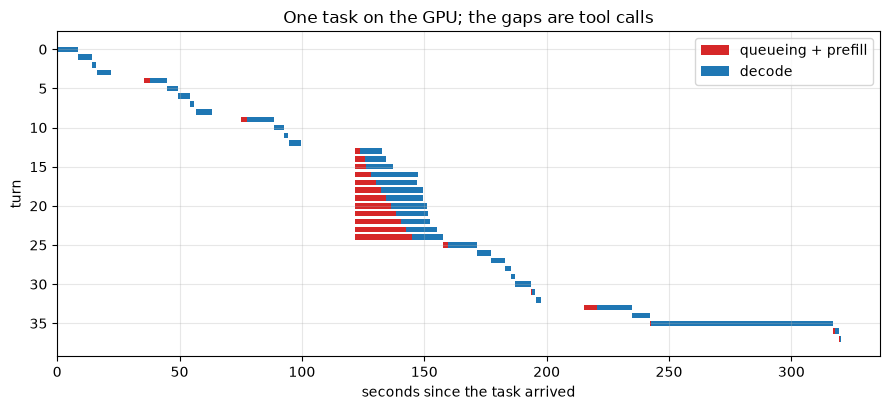

In [13]:
r = lsg.simulate(**SYSTEM, trace=trace, num_requests=len(sessions), qps=0.1,
                 prefix_caching=True, max_tokens=65536)
q = r.requests.assign(session=lambda d: d["Request Id"] // 1000,
                      turn=lambda d: d["Request Id"] % 1000)
s4 = q[q.session == 4].sort_values("turn")
t0 = s4.request_arrived_at.min()

fig, ax = plt.subplots(figsize=(9, 4.2))
for _, x in s4.iterrows():
    a = x.request_arrived_at - t0
    ax.barh(x.turn, x.prefill_e2e_time, left=a, color="C3", height=.7)
    ax.barh(x.turn, x.request_e2e_time - x.prefill_e2e_time,
            left=a + x.prefill_e2e_time, color="C0", height=.7)
ax.barh(0, 0, color="C3", label="queueing + prefill")
ax.barh(0, 0, color="C0", label="decode")
ax.set(xlabel="seconds since the task arrived", ylabel="turn",
       title="One task on the GPU; the gaps are tool calls")
ax.legend(loc="upper right")
ax.invert_yaxis()
fig.tight_layout()

In [14]:
tool4 = sessions[sessions.session == 4]
breakdown = pd.Series({
    "task completion time (s)": (s4.request_arrived_at + s4.request_e2e_time).max() - t0,
    "summed over its turns: decode (s)": (s4.request_e2e_time - s4.prefill_e2e_time).sum(),
    "summed over its turns: prefill (s)": s4.prefill_time_execution_plus_preemption.sum(),
    "summed over its turns: queueing (s)": s4.request_scheduling_delay.sum(),
    # Siblings released by one fan-out all waited for the same tool call, so count it once.
    "waiting for tools (s)": tool4.groupby(tool4.dep.map(tuple)).tool_time.max().sum(),
})
breakdown.round(1)

task completion time (s)               320.2
summed over its turns: decode (s)      364.0
summed over its turns: prefill (s)      37.2
summed over its turns: queueing (s)    120.3
waiting for tools (s)                   66.6
dtype: float64

Three things to read off the picture. First, the task is a chain: for most of its
life exactly one of its turns is running, so a GPU twice as fast would shorten
each bar without removing the serialisation between them. Second, the blue
(decode) parts dominate — summed over the turns, decode takes about 6 minutes
against 37 s of actual prefill, with tool calls adding about a minute — even
though every prompt is 10–50× longer than the answer it produces. Third, the
twelve-way fan-out is the one place where the serving system controls the task's
progress: a dozen bars start together, the replica prefills them more or less one
after another, and the turn that joins them waits for the last.

The sums in the table exceed the task's wall-clock time because of that fan-out:
twelve turns run at once, and most of the 2 minutes of queueing is those siblings
waiting for each other.

## A busier cluster

One task at a time is not a serving problem. Let's load 100 recorded tasks and
run them against four replicas (eight GPUs), one new task per second. Note what
"load" means here: the arrival rate matters much less than it did in lecture 2,
because a session only ever has a turn or two in flight. Adding load means adding
concurrent *tasks*, not sending requests faster.

In [15]:
busy_sessions = lsg.gaia_sessions(num_sessions=100, seed=0)
busy_trace = lsg.gaia_trace(busy_sessions)
print(f"{len(busy_sessions)} requests, "
      f"{busy_sessions.num_prefill_tokens.sum() / 1e6:.1f}M prompt tokens")

2515 requests, 7.1M prompt tokens


### Routing: cache affinity against load balance

Each replica keeps its own KV cache, so a request only hits what the replica it
lands on happens to hold. An agent session is a long chain of requests that all
want the same prefix, so the router decides the hit rate. This
is why production agent stacks care about routing at all: NVIDIA's
[Dynamo](https://github.com/ai-dynamo/dynamo) scores replicas by the prompt
tokens they would still have to compute as well as by load, and Mooncake routes
around a cluster-wide KV store instead. We compare three of the simulator's
policies, plus plain least-outstanding-requests as a cache-blind baseline.

In [16]:
routing = {}
for policy in ("round_robin", "lor", "sticky_lor", "dynamo_kv"):
    r = lsg.simulate(**SYSTEM, trace=busy_trace, num_requests=len(busy_sessions), qps=1.0,
                     num_replicas=4, prefix_caching=True, global_scheduler=policy,
                     max_tokens=65536)
    t = task_times(r)
    routing[policy] = {"KV cache hit rate": r.cache_hit_rate, "task time p50 (s)": t.median(),
                       "task time p90 (s)": t.quantile(0.9),
                       **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)"]]}
pd.DataFrame(routing).T.round(2)

,KV cache hit rate,task time p50 (s),task time p90 (s),TTFT p50 (ms),TTFT p99 (ms)
round_robin,0.36,252.45,665.62,312.73,9963.01
lor,0.43,236.51,649.56,279.05,8634.94
sticky_lor,0.56,226.54,613.84,148.53,25841.45
dynamo_kv,0.47,234.12,667.01,327.35,28061.16


`round_robin` ignores history and loses a third of the available hits. `lor`
(least outstanding requests) recovers some of them without trying, because an
idle replica is often the one that just finished this session's previous turn.
`sticky_lor`, which pins a session to one replica for its whole life, gets
closest to the single-replica hit rate and wins on median task time and median
TTFT.

The tails go the other way: both cache-aware policies are two to three times
worse at p99 than plain round-robin. Affinity means staying on a replica even
when it has just been handed a twelve-way fan-out, and the siblings of that burst
pay for it. Which side of that trade to take depends on whether the deployment is
judged on the median or the tail; lecture 8 looks at routing on its own.

### Scheduling: whose turn goes first

Inside a replica, the waiting queue is FCFS by default. The simulator offers two
alternatives aimed at agent workloads: `session_priority` orders waiting requests
by the age of their *session*, so a task that started long ago is not overtaken
by a brand-new one; and `sjf_priority` orders by the prompt tokens actually left
to compute, after subtracting the prefix-cache hit. The second is interesting
here because many turns have almost nothing to prefill — a cached 9,000-token
prompt plus 100 new tokens — and under FCFS they wait behind newcomers that have
all 9,000 still to do.

In [17]:
policies = {"FCFS": {},
            "session FCFS": {"--vllm_v1_scheduler_config_session_priority": True},
            "shortest job first": {"--vllm_v1_scheduler_config_sjf_priority": True}}
sched = {}
for name, extra in policies.items():
    r = lsg.simulate(**SYSTEM, trace=busy_trace, num_requests=len(busy_sessions), qps=1.0,
                     prefix_caching=True, max_tokens=65536, extra=extra)
    t = task_times(r)
    sched[name] = {"task time p50 (s)": t.median(), "task time p90 (s)": t.quantile(0.9),
                   **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)",
                                  "total execution time (s)"]]}
pd.DataFrame(sched).T.round(2)

,task time p50 (s),task time p90 (s),TTFT p50 (ms),TTFT p99 (ms),total execution time (s)
FCFS,554.99,1100.30,2349.40,65331.09,2042.96
session FCFS,578.09,1108.60,751.61,158406.60,2041.22
shortest job first,479.71,1047.83,578.51,68220.81,2033.88


On a single replica carrying 100 tasks, shortest-job-first shortens the median
task by about 13% and the median TTFT by 4×: letting the cheap turns through
first keeps many sessions moving instead of parking them behind one long prefill.
Ordering by session age does the opposite at the tail, protecting old sessions by
making new ones wait.

What none of them changes is the total execution time, because queue order
redistributes waiting rather than creating GPU capacity. And on the lightly
loaded replica of the previous section the same policies change the task time by
a fraction of a percent: there is almost nothing in the queue to reorder, and the
critical path is the session's own chain of decodes and tool calls.

## What this means for a serving system

| Observation | Consequence |
|---|---|
| Turns are dependent; a task is a chain | Task latency ≈ sum over turns of (queue + prefill + decode + tool). Throughput optimisations that lengthen any turn hurt the user directly. |
| Prompts are ~11× the output in tokens | Prefill-heavy: large chunk sizes, prefill-side capacity, and prefix caching all matter (lectures 3–5). |
| Output tokens cost ~200× more each | But most *time* is decode. Expect the decode pool, not the prefill pool, to size the cluster (lecture 4). |
| ~60% of prompt tokens are a repeat | Prefix caching matters more here than in any workload so far, and the router has to preserve it. |
| Fan-out bursts of a dozen requests | Admission and scheduling decide when the join unblocks; p99 TTFT of a *batch of siblings* is what matters, not p99 over all requests. |
| Idle gaps while tools run | A session holds KV cache it is not using. Evicting it costs a re-prefill; keeping it costs memory. |
| Each role is a different model | A real deployment of this system sizes and tunes two pools, not one (lecture 4). |

## What is realistic here, and what is not

The traces are real; the deployment around them is a lab. Before quoting any
number from this lecture:

| | In this lecture | In a production agent deployment |
|---|---|---|
| Models | one 32B model serves every role | at least two, chosen per role, on separately sized pools |
| Task mix | 24 (or 100) tasks that fit the course's context limit | the same system also runs tasks with 100k-token requests, which are the expensive ones |
| Tool latency | replayed from a benchmark that re-ran each tool offline | live, variable, and occasionally much slower than the recording |
| Agent overhead | zero: a turn is released the instant its dependency and tool finish | parsing, orchestration and retries add their own time between turns |
| Arrivals | Poisson over recorded tasks | diurnal, bursty, and correlated with the tasks people are running |
| KV cache | GPU-resident, per replica, no offload | tiered and often cluster-wide (lecture 5) |
| Failure | none; every recorded task is replayed as it happened | agents retry, loop, and abandon tasks, which changes the shape of the load |

What does carry over is the structure of the workload — dependent turns, fan-out
bursts, a prompt that grows by appending, tool gaps, and a task-level metric that
behaves very differently from a request-level one.

## Exercises

:::{admonition} Try it
:class: exercise

1. **Does the cache survive the tool call?** Rerun the caching comparison with a
   small KV cache (`kv_blocks=4000`, lecture 5) and look at `r.cache`. How many
   blocks are evicted, what happens to the hit rate, and do the sessions with the
   longest tool waits lose more than the others?
2. **Chunk size for agents.** The runs above used the default `chunk_size=512`.
   Sweep 512, 2048, 4096 on the single-replica run and report TTFT and task time.
   Why does a chunk size that was bad for chat (lecture 3) look better here, and
   does prefix caching being on change the answer?
3. **Disaggregate.** Build a PD cluster with lecture 4's `pd_cluster` helper
   (four replicas, splits 1:3, 2:2, 3:1) and run the busy trace. Which split wins,
   and does prefix caching change the answer? (Hint: what is the prefill pool's
   hit rate if a session's turns go to different prefill replicas?)
4. **The cost of a fan-out.** In the single-session timeline, measure how long
   the join turn (`dep` with twelve entries) waits after the *first* of its
   dependencies finishes. How much of that is queueing behind its own siblings,
   and what would a scheduler have to know to shorten it?
5. **Size the two pools.** Using the `model` column, work out how much GPU time
   each of the two models would need for this workload: count prompt and output
   tokens per model and price them at the ~0.25 ms and ~45 ms per token measured
   above. If you had eight GPUs, how would you split them, and which pool would
   saturate first? Then check your reasoning against what `lsg.gaia_sessions`
   shows about which roles sit on the critical path.
6. **A different sample.** Rerun the characterisation with `seed=1` and
   `num_sessions=48`. How stable are the prompt:output ratio and the ideal hit
   rate? What does that say about tuning a system to one trace?
:::

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [18]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "Why does an agent's prompt grow from turn to turn?",
     "options": ["The model remembers more each time",
                 "The model has no memory between requests, so every turn re-sends the conversation plus the new tool output",
                 "The system pads prompts to a block boundary"],
     "answer": 1,
     "explain": "Each request is independent. Continuity is created by resending everything, which is exactly why the prefix cache works so well here."},
    {"q": "Agent traffic has about 11 prompt tokens per output token. Where does most of the GPU <i>time</i> go?",
     "options": ["Prefill, because there are far more prompt tokens",
                 "Decode, because each output token costs roughly 200× more than a prompt token"],
     "answer": 1,
     "explain": "Prefill is compute-bound and processes thousands of tokens per step; decode is memory-bound and produces one token per step per request."},
    {"q": "Prefix caching cut TTFT by 6× but task completion time by only about a quarter. Why?",
     "options": ["The KV cache hit rate was too low",
                 "Most of a task's time is decode and tool calls, which prefix caching does not touch",
                 "Task time is dominated by queueing"],
     "answer": 1,
     "explain": "The task's critical path is a chain of turns, each spending most of its time generating tokens or waiting for a tool."},
    {"q": "Twelve requests are released at once by a fan-out, and a later turn depends on all twelve. Which metric predicts the task's progress?",
     "options": ["The median TTFT of the twelve", "The maximum completion time among the twelve",
                 "The throughput of the replica"],
     "answer": 1,
     "explain": "A join waits for its slowest dependency, which is why tail latency within a sibling group matters more than averages."},
    {"q": "Why does sticky routing give the best median task time but a much worse tail in the four-replica run?",
     "options": ["Sticky routing disables prefix caching for new sessions",
                 "It keeps a session on the replica that holds its prefix even when that replica is temporarily overloaded",
                 "It sends every session to replica 0"],
     "answer": 1,
     "explain": "Affinity maximises hits but gives up the freedom to move work away from a busy replica, e.g. one that has just received a fan-out burst."},
    {"q": "Shortest-job-first improved the median task time but left the total execution time of the whole run unchanged. What does that tell you?",
     "options": ["The scheduler is broken",
                 "Queue order redistributes waiting time between tasks; it does not create GPU capacity",
                 "The workload was not actually loaded"],
     "answer": 1,
     "explain": "Total work is fixed. Scheduling decides who waits; only more hardware, less work (caching), or cheaper work shortens the run itself."},
    {"q": "A session waits 22 s for a tool. What is the dilemma for the replica holding its KV cache?",
     "options": ["Whether to keep the blocks (idle memory) or evict them (a full re-prefill when the turn returns)",
                 "Whether to decode ahead speculatively",
                 "Whether to switch the session to another model"],
     "answer": 0,
     "explain": "Tool gaps make the reuse distance long. This is the agentic version of lecture 5's eviction trade-off, and it is why cache capacity and offload matter for agents."},
    {"q": "The ideal KV cache hit rate on this trace is 60% rather than 95%. What limits it?",
     "options": ["The 16-token block size",
                 "Each new worker starts its own conversation with a different system prompt, and the fan-out requests share only their instructions",
                 "The traces were recorded with caching disabled"],
     "answer": 1,
     "explain": "Reuse follows the agent's structure. Within a worker's stretch of turns almost everything repeats; across workers and across the chunks of a fan-out, much less does."},
    {"q": "OWL served the reading-and-classifying roles with one model and the reasoning roles with another. What does this lecture do instead, and why does it matter?",
     "options": ["It uses the same two models, so nothing changes",
                 "It serves every role with one 32B model, so the two very different prompt:output shapes are merged into one pool that a real deployment would size separately",
                 "It drops the roles served by the smaller model"],
     "answer": 1,
     "explain": "In the recording the smaller model sees 33 prompt tokens per output token and the larger one about 7. Those are different serving problems, and lecture 4's replica groups are how you would give each its own pool."},
])